# visualize umineko everyday data using autoencoder3d

data: umineko 2018 back 1

In [1]:
import os

import matplotlib.pyplot as plt

import torch.optim as optim
from umap import UMAP
import plotly.express as px

import pickle
import numpy as np
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader

from deepview.calculate_results.data.umineko.umineko_data import (
    read_umineko_data,
    read_umineko_path,
    extract_data_from_year_back,
    label_dict,
    get_accel_batch_data,
)

from deepview.calculate_results.models.utils import (
    Resnet,
sliding_window,
data_loader_umineko,
load_weights,
MSEloss,
MSEloss_weighted,
# torch,
AE_eval_time_series,
AE_train_time_series_resnet,
AE_train_time_series,
majority_value,
# np,
adjust_learning_rate,
# tqdm
Autoencoder3d,
Autoencoder1d,
Autoencoder2d,
Autoencoder3d4
)

In [2]:
def standardization(input_array, mean, std, bias=0.0):
    return ((input_array - mean) / np.maximum(std, 10 ** -5)) + bias

In [3]:
back_label_path = r'D:\logbot-data\BioTaggerData\masterLabelsByOtsuka\animal_id.csv'
umi_root_path = r'D:\logbot-data\BioTaggerData\export\raw\umineko\v.1.0.0'
file_paths = read_umineko_path(umi_root_path)

year = '2018'
data_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko_%s.npy'%year
if os.path.exists(data_path):
    tmp = np.load(data_path, allow_pickle='TRUE').item()
    df_list = tmp['raw_data']
    df_clean_list = tmp['labeled_data']
    
selected_df, selected_clean_df = (
        extract_data_from_year_back(df_list, df_clean_list, 1))

selected_df['label_id'] = selected_df['label'].map(label_dict)
selected_clean_df['label_id'] = selected_clean_df['label'].map(label_dict)

# 将df_list没有标签的位置赋值-2，标记灰色，其他label正常标记。观察是否有label的标记能在不同灰色cluster中
# Replace NaN with -2 in column A
selected_df['label_id'] = selected_df['label_id'].fillna(-2)

device = 'cuda'
len_sw = 300
sensor_type = 'accel'
selected_columns = ['acc_x', 'acc_y', 'acc_z', 'label_id']  # without timestamps
selected_np = selected_df[selected_columns].values

data_np = selected_np[:,:-1]
print(data_np.shape)
mean = np.mean(data_np, axis=0)
std = np.std(data_np, axis=0)
print("mean:",mean)
print("std:",std)
tmp_b_stand = standardization(data_np, mean, std)

selected_np[:,:-1] = tmp_b_stand

tmp_b = sliding_window(selected_np, len_sw, len_sw)
# print(tmp_b.shape)

# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]

batch_size = 512
train_set_r = data_loader_umineko(data_b, label_b, device=device)
train_loader = DataLoader(train_set_r, batch_size=batch_size,
                          shuffle=False, drop_last=False)

C:\Users\dell\AppData\Local\Temp\ipykernel_44412\2513636858.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['label_id'] = selected_df['label'].map(label_dict)
C:\Users\dell\AppData\Local\Temp\ipykernel_44412\2513636858.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_clean_df['label_id'] = selected_clean_df['label'].map(label_dict)
C:\Users\dell\AppData\Local\Temp\ipykernel_44412\2513636858.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

(8404650, 3)
mean: [0.03523875 0.38986442 0.8461156 ]
std: [0.31962855 2.01546772 0.30623299]


In [10]:
model = Autoencoder3d4()
model = model.to(device)
# full_model_path = r'D:\code\DeepView\deepview\calculate_results\viz\AE3d4_reconstruct_epoch500_datalen300_accel.pth'
# if torch.cuda.is_available():
#     model.load_state_dict(torch.load(full_model_path, weights_only=False))
# else:
#     model.load_state_dict(torch.load(full_model_path, weights_only=False, map_location=torch.device('cpu')))

criterion = MSEloss_weighted()

criterion = criterion.to(device)

learning_rate = 0.001
# optimizer = optim.Adam(
#     model.parameters(), lr=learning_rate, amsgrad=True
# )
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [11]:
 # training
start_epoch = 0
num_epochs = 1000
# lr = 0.0001
training_loss = []
for epoch in tqdm(range(start_epoch, num_epochs)):

    # learning_rate = adjust_learning_rate(
    #     learning_rate, optimizer, epoch, p_scheduler='cosine', p_epochs=num_epochs)

    losses = AE_train_time_series_resnet(train_loader, model, criterion, optimizer, epoch, scheduler, device)
    training_loss.append(np.average(losses))
    # if (epoch % 10 == 0) or (epoch == num_epochs - 1):
    #     print('loss of the ' + str(epoch) + '-th training epoch is :' + losses.__str__())


print('Saving model at: ' + 'AE_reconstruct_epoch%s' % str(epoch) \
      + '_datalen%s_' % str(len_sw) +sensor_type+ '.pth')
torch.save(model.state_dict(), 'AE_reconstruct_epoch%s' % str(epoch) + \
           '_datalen%s_' % str(len_sw) +sensor_type+ '.pth')

100%|██████████| 1000/1000 [1:15:57<00:00,  4.56s/it]

Saving model at: AE_reconstruct_epoch999_datalen300_accel.pth


## reconstruction after training

C:\Users\dell\AppData\Local\Temp\ipykernel_44412\3805672116.py:48: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.

D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



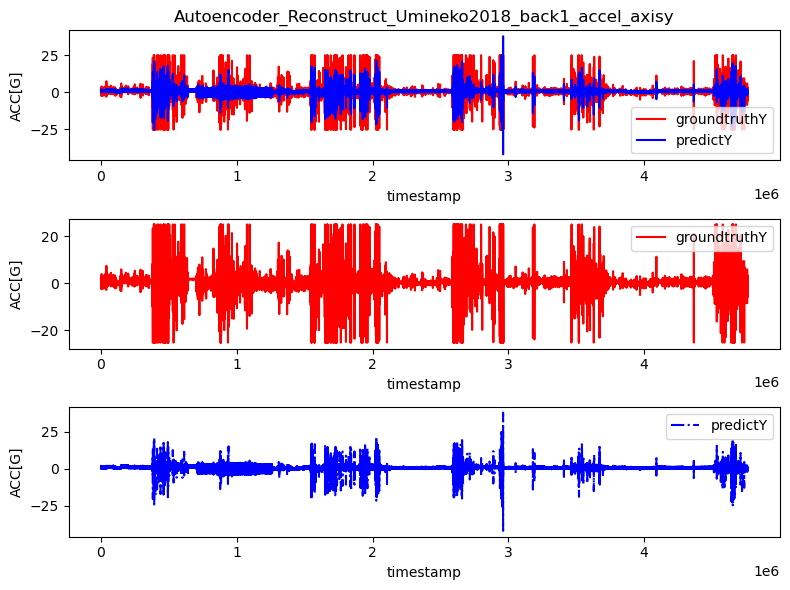

In [8]:
# reconstruction result
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)

# tsne latent representation to shape=(2, len) PCA降维到形状为 (2, len)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)

sample_concat = np.concatenate(sample_list)
# sample_reshape = sample_concat.reshape(-1, 3)
sample_concat = sample_concat.transpose(0, 2, 1)
sample_reshape = sample_concat.reshape(-1, sample_concat.shape[-1])

pred_concat = np.concatenate(pred_list)
# pred_reshape = pred_concat.reshape(-1, 3)
pred_concat = pred_concat.transpose(0, 2, 1)
pred_reshape = pred_concat.reshape(-1, pred_concat.shape[-1])

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)
# label_concat_vote.shape

start, end = 0, -1
col = 0
fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].plot(sample_reshape[start:end, col], 'r', label='groundtruthY')
axes[0].plot(pred_reshape[start:end, col], 'b-', label='predictY')
axes[0].set_title('Autoencoder_Reconstruct_Umineko2018_back1_accel_axisy')
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend()

axes[1].plot(sample_reshape[start:end, col], 'r', label='groundtruthY')
# axes[1].plot(pred_reshape[10000:length, 1], 'b-.', label='predictY')
# axes[1].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend()

# axes[2].plot(sample_reshape[10000:length, 1], 'r', label='groundtruthY')
axes[2].plot(pred_reshape[start:end, col], 'b-.', label='predictY')
# axes[2].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend()

# Adjust layout
plt.tight_layout()
# Show the figure
plt.show()
# autoencoder3d

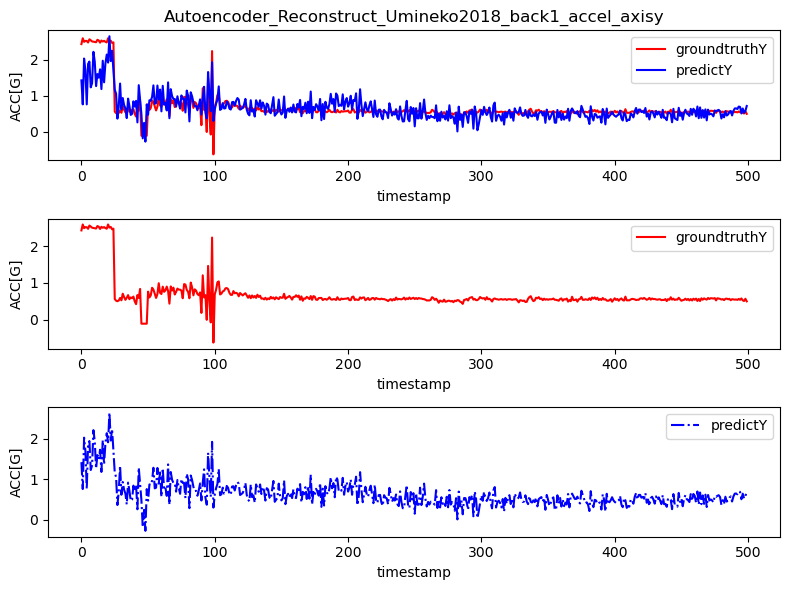

In [12]:
# reconstruction result
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)

# tsne latent representation to shape=(2, len) PCA降维到形状为 (2, len)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)

sample_concat = np.concatenate(sample_list)
# sample_reshape = sample_concat.reshape(-1, 3)
sample_concat = sample_concat.transpose(0, 2, 1)
sample_reshape = sample_concat.reshape(-1, sample_concat.shape[-1])

pred_concat = np.concatenate(pred_list)
# pred_reshape = pred_concat.reshape(-1, 3)
pred_concat = pred_concat.transpose(0, 2, 1)
pred_reshape = pred_concat.reshape(-1, pred_concat.shape[-1])

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)
# label_concat_vote.shape

start, end = 0, 500
col = 0
fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].plot(sample_reshape[start:end, col], 'r', label='groundtruthY')
axes[0].plot(pred_reshape[start:end, col], 'b-', label='predictY')
axes[0].set_title('Autoencoder_Reconstruct_Umineko2018_back1_accel_axisy')
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend()

axes[1].plot(sample_reshape[start:end, col], 'r', label='groundtruthY')
# axes[1].plot(pred_reshape[10000:length, 1], 'b-.', label='predictY')
# axes[1].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend()

# axes[2].plot(sample_reshape[10000:length, 1], 'r', label='groundtruthY')
axes[2].plot(pred_reshape[start:end, col], 'b-.', label='predictY')
# axes[2].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend()

# Adjust layout
plt.tight_layout()
# Show the figure
plt.show()

# latent representation

In [13]:

umap_3d = UMAP(n_components=3)

proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

# set point size 
point_size = np.ones(proj_3d_gyro.shape[0]) * 1
grey_idx = np.where(label_concat_vote==-2)[0]
point_size[grey_idx] = 0.5

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote.astype(str),  
    labels={'color': 'activity'},
    # color_discrete_map={ '-2.0': ('rgba(239, 239, 240, 1)')},
    color_discrete_map={ '-2.0': 'grey'},
    size=point_size
)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())

fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point

fig_3d.show()

In [14]:
umap_3d = UMAP(n_components=2)

proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

# set point size 
point_size = np.ones(proj_3d_gyro.shape[0]) * 0.1
grey_idx = np.where(label_concat_vote==-2)[0]
point_size[grey_idx] = 0.05

fig_3d = px.scatter(
    proj_3d_gyro, x=0, y=1,
    color=label_concat_vote.astype(str),  
    labels={'color': 'activity'},
    # color_discrete_map={ '-2.0': ('rgba(239, 239, 240, 1)')},
    color_discrete_map={ '-2.0': 'grey'},
    size=point_size
)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())

fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point

fig_3d.show()

In [ ]:
# only show the activities of -2 and 0

# find indices
value_idx = np.where((label_concat_vote==-2) | (label_concat_vote==0))[0]

fig_3d = px.scatter_3d(
    proj_3d_gyro[value_idx, :], x=0, y=1, z=2,
    color=label_concat_vote[value_idx].astype(str),  
    labels={'color': 'activity'},
    # color_discrete_map={ '-2.0': ('rgba(239, 239, 240, 1)')},
    color_discrete_map={ '-2.0': 'grey'},
    size=point_size[value_idx]
)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())

fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point

fig_3d.show()

In [9]:

umap_3d = UMAP(n_components=3)

proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

# set point size 
point_size = np.ones(proj_3d_gyro.shape[0]) * 1
grey_idx = np.where(label_concat_vote==-2)[0]
point_size[grey_idx] = 0.5

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote.astype(str),  
    labels={'color': 'activity'},
    # color_discrete_map={ '-2.0': ('rgba(239, 239, 240, 1)')},
    color_discrete_map={ '-2.0': 'grey'},
    size=point_size
)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())

fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point

fig_3d.show()
# autoencoder3d

In [15]:
umap_3d = UMAP(n_components=2)

proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

# set point size 
point_size = np.ones(proj_3d_gyro.shape[0]) * 0.1
grey_idx = np.where(label_concat_vote==-2)[0]
point_size[grey_idx] = 0.05

fig_3d = px.scatter(
    proj_3d_gyro, x=0, y=1,
    color=label_concat_vote.astype(str),  
    labels={'color': 'activity'},
    # color_discrete_map={ '-2.0': ('rgba(239, 239, 240, 1)')},
    color_discrete_map={ '-2.0': 'grey'},
    size=point_size
)

# Update transparency for traces where activity is '-2.0'
fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())

fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point

fig_3d.show()
# autoencoder3d